In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from sklearn.metrics import f1_score

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)



In [24]:


#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
    ])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)



In [25]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Significantly reduced filters compared to the "Large" model
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1) 
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1)
        
        # Smaller hidden layer
        self.fc1 = nn.Linear(128 * 2 * 2, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [26]:

# 6. Initialize Network
model = SmallCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [27]:

# 7. Training Function
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    gradient_norms = {}
    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)
    
    train_f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, gradient_norms, train_f1


In [28]:

# 8. Testing Function
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)
    
    test_f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, test_f1


In [29]:
# --- 1. Settings for Smaller Model Solution ---
num_epochs = 50 
model = SmallCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Storage for plots (Required for Task 3)
train_losses, test_losses = [], []
train_accs, test_accs = [], []
train_f1s, test_f1s = [], []

print("Starting Task 3: Smaller Model Strategy...")

for epoch in range(num_epochs):
    # 2. Standard train/test steps
    train_loss, train_acc, _, train_f1 = train(model, train_loader)
    val_loss, val_acc, val_f1 = test(model, test_loader)

    # 3. Store metrics
    train_losses.append(train_loss)
    test_losses.append(val_loss)
    train_accs.append(train_acc)
    test_accs.append(val_acc)
    train_f1s.append(train_f1)
    test_f1s.append(val_f1)

    # 4. Monitoring
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Validation Loss: {val_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}% | Validation Acc: {val_acc:.2f}%")
    print(f"Train F1: {train_f1:.4f} | Validation F1: {val_f1:.4f}")
    print("-" * 40)

Starting Task 3: Smaller Model Strategy...
Epoch 1/50
Train Loss: 1.6508 | Validation Loss: 1.4099
Train Acc: 38.47% | Validation Acc: 47.71%
Train F1: 0.3762 | Validation F1: 0.4626
----------------------------------------
Epoch 2/50
Train Loss: 1.2969 | Validation Loss: 1.2292
Train Acc: 53.08% | Validation Acc: 55.78%
Train F1: 0.5270 | Validation F1: 0.5531
----------------------------------------
Epoch 3/50
Train Loss: 1.1193 | Validation Loss: 1.0884
Train Acc: 59.95% | Validation Acc: 61.32%
Train F1: 0.5969 | Validation F1: 0.6166
----------------------------------------
Epoch 4/50
Train Loss: 0.9873 | Validation Loss: 0.9809
Train Acc: 64.88% | Validation Acc: 65.45%
Train F1: 0.6470 | Validation F1: 0.6545
----------------------------------------
Epoch 5/50
Train Loss: 0.8912 | Validation Loss: 0.9705
Train Acc: 68.65% | Validation Acc: 66.15%
Train F1: 0.6851 | Validation F1: 0.6582
----------------------------------------
Epoch 6/50
Train Loss: 0.8159 | Validation Loss: 0.9

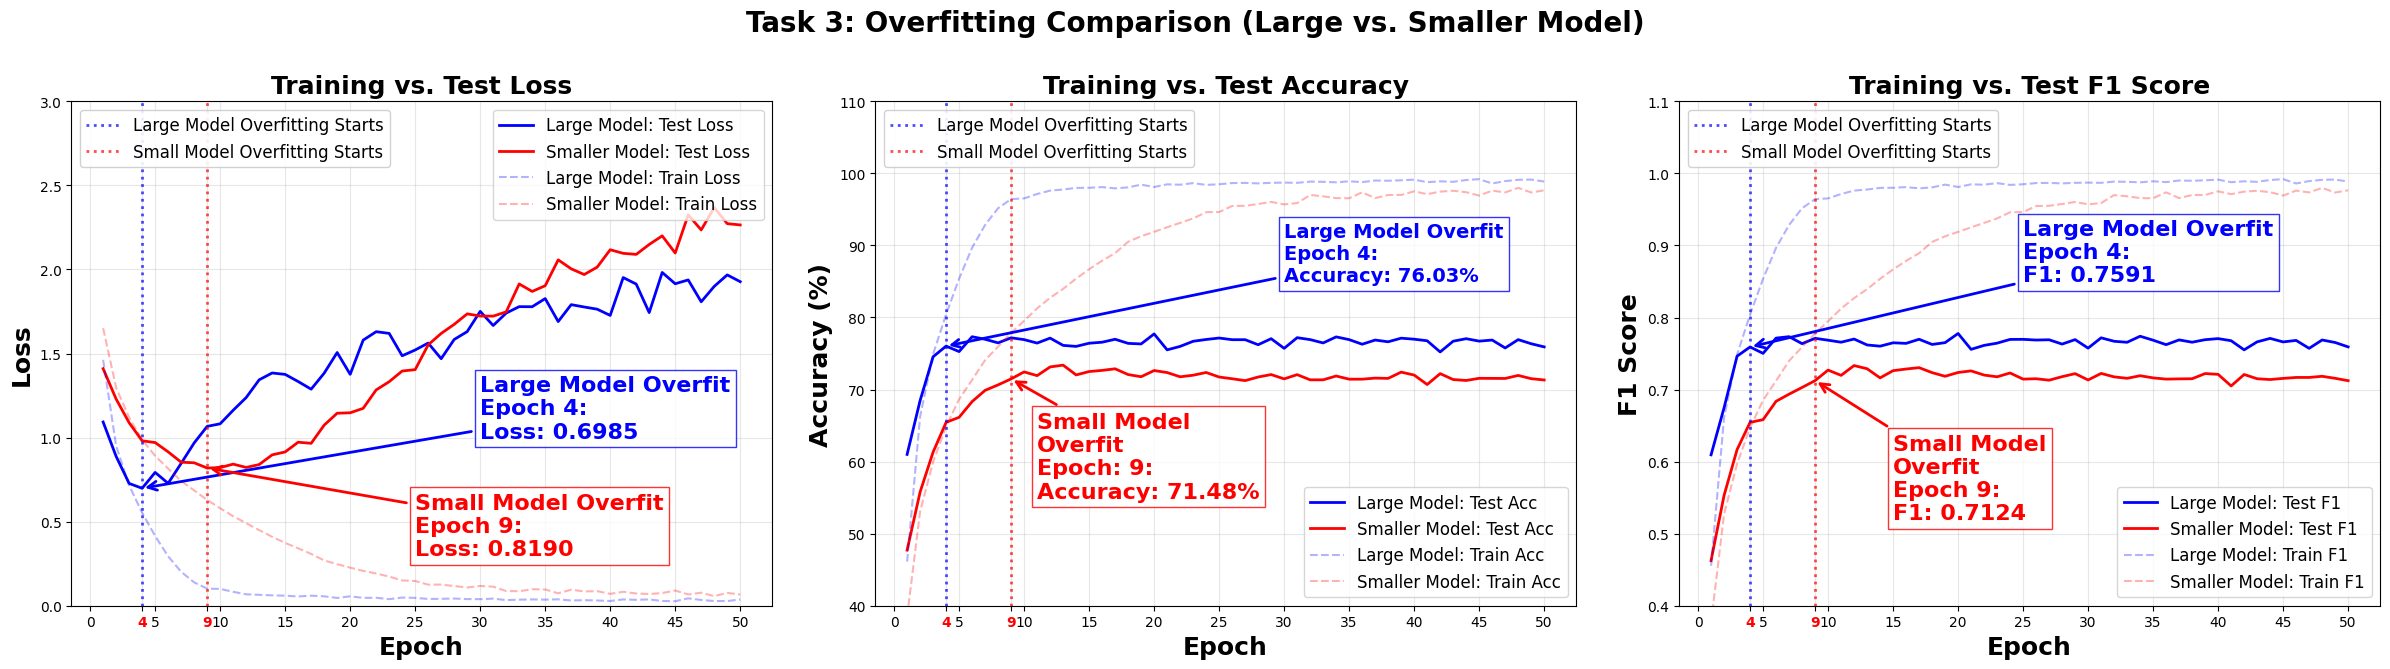

In [68]:
import matplotlib.pyplot as plt

# 1. Dataset 1: Large Model (Unregulated) - Hardcoded
epochs = list(range(1, 51))


# ----------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------
# Large Model (Unregulated)
# ----------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------
large_train_loss = [
    1.4626, 0.9511, 0.7157, 0.5530, 0.4145, 0.2939, 0.2019, 0.1389, 0.1015, 0.1001,
    0.0827, 0.0679, 0.0649, 0.0616, 0.0597, 0.0551, 0.0597, 0.0559, 0.0462, 0.0559,
    0.0466, 0.0472, 0.0391, 0.0486, 0.0467, 0.0401, 0.0411, 0.0427, 0.0394, 0.0390,
    0.0422, 0.0335, 0.0360, 0.0374, 0.0362, 0.0379, 0.0311, 0.0330, 0.0311, 0.0281,
    0.0373, 0.0351, 0.0375, 0.0281, 0.0268, 0.0439, 0.0342, 0.0280, 0.0276, 0.0372
]

large_val_loss = [
    1.0928, 0.8882, 0.7274, 0.6985, 0.7929, 0.7279, 0.8467, 0.9681, 1.0667, 1.0820,
    1.1625, 1.2379, 1.3436, 1.3843, 1.3759, 1.3334, 1.2879, 1.3831, 1.5060, 1.3764,
    1.5796, 1.6299, 1.6198, 1.4866, 1.5210, 1.5623, 1.4692, 1.5835, 1.6303, 1.7507,
    1.6667, 1.7406, 1.7788, 1.7783, 1.8268, 1.6902, 1.7907, 1.7768, 1.7637, 1.7267,
    1.9518, 1.9131, 1.7435, 1.9822, 1.9150, 1.9378, 1.8079, 1.8993, 1.9677, 1.9274
]

large_train_acc = [
    46.12, 66.24, 74.91, 80.44, 85.39, 89.68, 92.85, 95.17, 96.43, 96.53,
    97.14, 97.61, 97.76, 97.99, 98.00, 98.10, 97.92, 98.06, 98.44, 98.11,
    98.48, 98.43, 98.65, 98.40, 98.49, 98.66, 98.68, 98.61, 98.69, 98.72,
    98.69, 98.86, 98.83, 98.76, 98.90, 98.79, 99.01, 98.98, 99.04, 99.13,
    98.78, 98.90, 98.83, 99.08, 99.20, 98.60, 98.93, 99.11, 99.14, 98.87
]

large_val_acc = [
    61.00, 68.47, 74.55, 76.03, 75.27, 77.33, 76.98, 76.48, 77.18, 76.93,
    76.45, 77.14, 76.13, 75.99, 76.43, 76.57, 76.98, 76.41, 76.33, 77.72,
    75.51, 75.99, 76.70, 76.95, 77.15, 76.92, 76.92, 76.22, 77.06, 75.72,
    77.20, 76.93, 76.47, 77.31, 76.93, 76.29, 76.87, 76.63, 77.13, 76.99,
    76.77, 75.22, 76.71, 77.06, 76.72, 76.87, 75.77, 76.93, 76.36, 75.92
]

large_train_f1 = [
    0.4555, 0.6608, 0.7484, 0.8040, 0.8537, 0.8967, 0.9284, 0.9517, 0.9642, 0.9653,
    0.9714, 0.9761, 0.9776, 0.9799, 0.9800, 0.9810, 0.9792, 0.9806, 0.9844, 0.9811,
    0.9848, 0.9843, 0.9865, 0.9840, 0.9849, 0.9866, 0.9868, 0.9861, 0.9869, 0.9872,
    0.9869, 0.9886, 0.9883, 0.9876, 0.9890, 0.9879, 0.9901, 0.9898, 0.9904, 0.9913,
    0.9878, 0.9890, 0.9883, 0.9908, 0.9920, 0.9860, 0.9893, 0.9911, 0.9914, 0.9887
]

large_val_f1 = [
    0.6094, 0.6747, 0.7463, 0.7591, 0.7502, 0.7714, 0.7734, 0.7637, 0.7711, 0.7685,
    0.7657, 0.7701, 0.7619, 0.7602, 0.7649, 0.7641, 0.7698, 0.7626, 0.7651, 0.7778,
    0.7558, 0.7613, 0.7644, 0.7696, 0.7697, 0.7687, 0.7691, 0.7631, 0.7693, 0.7575,
    0.7718, 0.7670, 0.7656, 0.7740, 0.7685, 0.7623, 0.7689, 0.7657, 0.7692, 0.7707,
    0.7678, 0.7551, 0.7662, 0.7710, 0.7661, 0.7682, 0.7572, 0.7688, 0.7653, 0.7592
]

# ----------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------
# 2. Dataset 2: Smaller Model Strategy - Hardcoded
# ----------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------
small_train_loss = [
    1.6508, 1.2969, 1.1193, 0.9873, 0.8912, 0.8159, 0.7418, 0.6858, 0.6294, 0.5797,
    0.5323, 0.4911, 0.4496, 0.4099, 0.3735, 0.3415, 0.3081, 0.2693, 0.2473, 0.2266,
    0.2072, 0.1919, 0.1733, 0.1503, 0.1470, 0.1254, 0.1257, 0.1171, 0.1082, 0.1177,
    0.1133, 0.0872, 0.0863, 0.0982, 0.0966, 0.0740, 0.0953, 0.0851, 0.0866, 0.0707,
    0.0828, 0.0729, 0.0697, 0.0753, 0.0904, 0.0669, 0.0776, 0.0570, 0.0763, 0.0668
]

small_val_loss = [
    1.4099, 1.2292, 1.0884, 0.9809, 0.9705, 0.9152, 0.8537, 0.8502, 0.8190, 0.8214,
    0.8422, 0.8225, 0.8396, 0.8973, 0.9147, 0.9725, 0.9659, 1.0741, 1.1450, 1.1475,
    1.1740, 1.2836, 1.3325, 1.3959, 1.4043, 1.5516, 1.6195, 1.6735, 1.7359, 1.7230,
    1.7224, 1.7477, 1.9138, 1.8693, 1.9034, 2.0572, 2.0039, 1.9698, 2.0140, 2.1173,
    2.0959, 2.0896, 2.1486, 2.2000, 2.0979, 2.3250, 2.2351, 2.3688, 2.2725, 2.2648
]

small_train_acc = [
    38.47, 53.08, 59.95, 64.88, 68.65, 71.34, 74.08, 75.96, 77.86, 79.53,
    81.27, 82.74, 83.97, 85.39, 86.70, 87.88, 88.94, 90.51, 91.28, 91.89,
    92.52, 93.13, 93.75, 94.62, 94.64, 95.48, 95.50, 95.75, 96.04, 95.70,
    95.88, 97.00, 96.82, 96.57, 96.55, 97.37, 96.57, 97.00, 97.01, 97.51,
    97.12, 97.47, 97.59, 97.39, 96.92, 97.61, 97.36, 97.99, 97.35, 97.65
]

small_val_acc = [
    47.71, 55.78, 61.32, 65.45, 66.15, 68.33, 69.89, 70.65, 71.48, 72.45,
    71.93, 73.14, 73.39, 72.03, 72.50, 72.66, 72.88, 72.08, 71.78, 72.64,
    72.36, 71.77, 71.99, 72.37, 71.74, 71.50, 71.24, 71.74, 72.08, 71.48,
    72.07, 71.35, 71.35, 71.88, 71.44, 71.44, 71.59, 71.55, 72.42, 72.01,
    70.70, 72.21, 71.39, 71.26, 71.56, 71.55, 71.54, 71.96, 71.51, 71.33
]

small_train_f1 = [
    0.3762, 0.5270, 0.5969, 0.6470, 0.6851, 0.7122, 0.7398, 0.7589, 0.7778, 0.7948,
    0.8123, 0.8269, 0.8393, 0.8536, 0.8667, 0.8786, 0.8892, 0.9049, 0.9127, 0.9188,
    0.9251, 0.9313, 0.9375, 0.9461, 0.9463, 0.9547, 0.9550, 0.9575, 0.9604, 0.9570,
    0.9588, 0.9699, 0.9682, 0.9657, 0.9655, 0.9737, 0.9657, 0.9700, 0.9701, 0.9751,
    0.9712, 0.9747, 0.9759, 0.9739, 0.9692, 0.9761, 0.9736, 0.9799, 0.9735, 0.9765
]

small_val_f1 = [
    0.4626, 0.5531, 0.6166, 0.6545, 0.6582, 0.6837, 0.6936, 0.7029, 0.7124, 0.7270,
    0.7197, 0.7333, 0.7289, 0.7162, 0.7262, 0.7285, 0.7304, 0.7235, 0.7184, 0.7237,
    0.7259, 0.7201, 0.7177, 0.7230, 0.7145, 0.7150, 0.7130, 0.7179, 0.7221, 0.7133,
    0.7224, 0.7176, 0.7156, 0.7192, 0.7162, 0.7145, 0.7148, 0.7150, 0.7222, 0.7211,
    0.7050, 0.7209, 0.7150, 0.7139, 0.7155, 0.7168, 0.7168, 0.7184, 0.7156, 0.7123
]

# Identifying Overfitting points (min validation loss)
large_overfit_ep = 4
small_overfit_ep = 9

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Task 3: Overfitting Comparison (Large vs. Smaller Model)', fontsize=20, fontweight='bold')

# --- Plot 1: Loss ---
ax1.plot(epochs, large_val_loss, label='Large Model: Test Loss', color='blue', linewidth=2)
ax1.plot(epochs, small_val_loss, label='Smaller Model: Test Loss', color='red', linewidth=2)
ax1.plot(epochs, large_train_loss, label='Large Model: Train Loss', color='blue', alpha=0.3, linestyle='--')
ax1.plot(epochs, small_train_loss, label='Smaller Model: Train Loss', color='red', alpha=0.3, linestyle='--')

# Overfitting values
large_overfit_loss = large_val_loss[large_overfit_ep - 1]
small_overfit_loss = small_val_loss[small_overfit_ep - 1]

# Vertical dashed lines
ax1.axvline(x=large_overfit_ep, color='blue', linestyle=':', linewidth=2, alpha=0.7)
ax1.axvline(x=small_overfit_ep, color='red', linestyle=':', linewidth=2, alpha=0.7)

# Arrows
ax1.annotate(
    f'Large Model Overfit\nEpoch {large_overfit_ep}:\nLoss: {large_overfit_loss:.4f}',
    xy=(large_overfit_ep, large_overfit_loss),
    xytext=(30, 1),
    arrowprops=dict(arrowstyle='->', color='blue', linewidth=2),
    color='blue',
    fontsize=16,
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='blue', alpha=0.8)
)

ax1.annotate(
    f'Small Model Overfit\nEpoch {small_overfit_ep}:\nLoss: {small_overfit_loss:.4f}',
    xy=(small_overfit_ep, small_overfit_loss),
    xytext=(25, 0.3),
    arrowprops=dict(arrowstyle='->', color='red', linewidth=2),
    color='red',
    fontsize=16,
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='red', alpha=0.8)
)

ax1.set_title('Training vs. Test Loss', fontsize=18, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=18, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=18, fontweight='bold')
ax1.set_ylim(0, 3)
curve_legend1 = ax1.legend(fontsize=12, loc='upper right')
line_handles1 = [
    mlines.Line2D([], [], color='blue', linestyle=':', linewidth=2, alpha=0.7),
    mlines.Line2D([], [], color='red', linestyle=':', linewidth=2, alpha=0.7)
]
legend_overfit1 = ax1.legend(
    line_handles1,
    ['Large Model Overfitting Starts', 'Small Model Overfitting Starts'],
    fontsize=12,
    loc='upper left',
    bbox_to_anchor=(0.0001, 0.99999),
    frameon=True,
    framealpha=0.9
)
ax1.add_artist(curve_legend1)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Accuracy ---
ax2.plot(epochs, large_val_acc, label='Large Model: Test Acc', color='blue', linewidth=2)
ax2.plot(epochs, small_val_acc, label='Smaller Model: Test Acc', color='red', linewidth=2)
ax2.plot(epochs, large_train_acc, label='Large Model: Train Acc', color='blue', alpha=0.3, linestyle='--')
ax2.plot(epochs, small_train_acc, label='Smaller Model: Train Acc', color='red', alpha=0.3, linestyle='--')

# Overfitting accuracy values
large_overfit_acc = large_val_acc[large_overfit_ep - 1]
small_overfit_acc = small_val_acc[small_overfit_ep - 1]

# Vertical dashed lines
ax2.axvline(x=large_overfit_ep, color='blue', linestyle=':', linewidth=2, alpha=0.7)
ax2.axvline(x=small_overfit_ep, color='red', linestyle=':', linewidth=2, alpha=0.7)

# Arrows
ax2.annotate(
    f'Large Model Overfit\nEpoch {large_overfit_ep}:\nAccuracy: {large_overfit_acc:.2f}%',
    xy=(large_overfit_ep, large_overfit_acc),
    xytext=(30, 85),
    arrowprops=dict(arrowstyle='->', color='blue', linewidth=2),
    color='blue',
    fontsize=14,
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='blue', alpha=0.8)
)

ax2.annotate(
    f'Small Model\nOverfit\nEpoch: {small_overfit_ep}:\nAccuracy: {small_overfit_acc:.2f}%',
    xy=(small_overfit_ep, small_overfit_acc),
    xytext=(11, 55),
    arrowprops=dict(arrowstyle='->', color='red', linewidth=2),
    color='red',
    fontsize=16,
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='red', alpha=0.8)
)

ax2.set_title('Training vs. Test Accuracy', fontsize=18, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=18, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=18, fontweight='bold')
ax2.set_ylim(40, 110)
curve_legend2 = ax2.legend(fontsize=12, loc='lower right')
line_handles2 = [
    mlines.Line2D([], [], color='blue', linestyle=':', linewidth=2, alpha=0.7),
    mlines.Line2D([], [], color='red', linestyle=':', linewidth=2, alpha=0.7)
]
legend_overfit2 = ax2.legend(
    line_handles2,
    ['Large Model Overfitting Starts', 'Small Model Overfitting Starts'],
    fontsize=12,
    loc='upper left',
    bbox_to_anchor=(0.0001, 0.9999),
    frameon=True,
    framealpha=0.9
)
ax2.add_artist(curve_legend2)
ax2.grid(True, alpha=0.3)

# --- Plot 3: F1 Score ---
ax3.plot(epochs, large_val_f1, label='Large Model: Test F1', color='blue', linewidth=2)
ax3.plot(epochs, small_val_f1, label='Smaller Model: Test F1', color='red', linewidth=2)
ax3.plot(epochs, large_train_f1, label='Large Model: Train F1', color='blue', alpha=0.3, linestyle='--')
ax3.plot(epochs, small_train_f1, label='Smaller Model: Train F1', color='red', alpha=0.3, linestyle='--')

# Overfitting F1 values
large_overfit_f1 = large_val_f1[large_overfit_ep - 1]
small_overfit_f1 = small_val_f1[small_overfit_ep - 1]

# Vertical dashed lines
ax3.axvline(x=large_overfit_ep, color='blue', linestyle=':', linewidth=2, alpha=0.7)
ax3.axvline(x=small_overfit_ep, color='red', linestyle=':', linewidth=2, alpha=0.7)

# Arrows
ax3.annotate(
    f'Large Model Overfit\nEpoch {large_overfit_ep}:\nF1: {large_overfit_f1:.4f}',
    xy=(large_overfit_ep, large_overfit_f1),
    xytext=(25, 0.85),
    arrowprops=dict(arrowstyle='->', color='blue', linewidth=2),
    color='blue',
    fontsize=16,
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='blue', alpha=0.8)
)

ax3.annotate(
    f'Small Model\nOverfit\nEpoch {small_overfit_ep}:\nF1: {small_overfit_f1:.4f}',
    xy=(small_overfit_ep, small_overfit_f1),
    xytext=(15, 0.52),
    arrowprops=dict(arrowstyle='->', color='red', linewidth=2),
    color='red',
    fontsize=16,
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='red', alpha=0.8)
)

ax3.set_title('Training vs. Test F1 Score', fontsize=18, fontweight='bold')
ax3.set_xlabel('Epoch', fontsize=18, fontweight='bold')
ax3.set_ylabel('F1 Score', fontsize=18, fontweight='bold')
ax3.set_ylim((0.4, 1.1))
curve_legend3 = ax3.legend(fontsize=12, loc='lower right')
line_handles3 = [
    mlines.Line2D([], [], color='blue', linestyle=':', linewidth=2, alpha=0.7),
    mlines.Line2D([], [], color='red', linestyle=':', linewidth=2, alpha=0.7)
]
legend_overfit3 = ax3.legend(
    line_handles3,
    ['Large Model Overfitting Starts', 'Small Model Overfitting Starts'],
    fontsize=12,
    loc='upper left',
    bbox_to_anchor=(0.0001, 0.9999),
    frameon=True,
    framealpha=0.9
)
ax3.add_artist(curve_legend3)
ax3.grid(True, alpha=0.3)

# Highlight Red Epoch Numbers on X-axis
for ax in [ax1, ax2, ax3]:
    ax.set_xticks(list(range(0, 51, 5)) + [large_overfit_ep, small_overfit_ep])
    labels = ax.get_xticklabels()
    for label in labels:
        if label.get_text() in [str(large_overfit_ep), str(small_overfit_ep)]:
            label.set_color('red')
            label.set_fontweight('bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()